## 1. Import Required Libraries

The required Python libraries are imported for model development and evaluation.

- **Pandas** is used for loading and manipulating the processed datasets.
- **NumPy** is used for numerical operations.
- **LinearRegression** is used to build the baseline linear regression model.
- **Ridge** is used to build a regularized linear regression model.
- **mean_squared_error** and **r2_score** are used to evaluate model performance.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Processed Datasets

The processed training and test datasets generated during the preprocessing stage are loaded from the `data` directory.

The training dataset contains **143,679 observations and 90 columns**, while the test dataset contains **35,920 observations and 90 columns**.

These datasets contain the transformed features required for model development. The training dataset also contains the log-transformed target variable, while the test dataset retains the original rental price for final model evaluation.

In [2]:
# Load the processed training and test datasets

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Training dataset shape:", train.shape)
print("Test dataset shape:", test.shape)

Training dataset shape: (143679, 90)
Test dataset shape: (35920, 90)


## 3. Separate Features and Target Variables

The processed datasets are separated into input features and target variables before model training.

For the training dataset, `price_log` is used as the target variable because the rental price was log-transformed during preprocessing to reduce target skewness.

For the test dataset, the original `price` variable is retained as the target so that the final predictions can be evaluated in the original rental-price scale.

The target columns are removed from the feature matrices to prevent target leakage.

In [3]:
# Separate training features and target
X_train = train.drop(columns=["price_log"])
y_train_log = train["price_log"]

# Separate test features and original target
X_test = test.drop(columns=["price"])
y_test = test["price"]

# Check the resulting shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_log.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (143679, 89)
y_train shape: (143679,)
X_test shape: (35920, 89)
y_test shape: (35920,)


## 4. Verify Feature Consistency and Target Leakage

Before training the regression models, the training and test feature sets are verified to ensure that they contain the same features in the same order.

A target leakage check is also performed to confirm that the rental price target variables are not accidentally included among the model input features.

This step is important because target leakage can produce unrealistically high model performance and make the evaluation unreliable.

In [4]:
# Check whether training and test features are identical
same_features = list(X_train.columns) == list(X_test.columns)

print("Training and test features match:", same_features)

# Check for target leakage
print("price_log in X_train:", "price_log" in X_train.columns)
print("price in X_train:", "price" in X_train.columns)

print("price_log in X_test:", "price_log" in X_test.columns)
print("price in X_test:", "price" in X_test.columns)

# Display total number of model features
print("Number of model features:", X_train.shape[1])

Training and test features match: True
price_log in X_train: False
price in X_train: False
price_log in X_test: False
price in X_test: False
Number of model features: 89


## 5. Train the Linear Regression Model

Linear Regression is used as the baseline regression model for predicting rental prices.

The model is trained using the 89 processed input features and the log-transformed rental price (`price_log`) as the target variable.

Using the log-transformed target helps reduce the influence of highly skewed rental prices during model training. The trained model will later generate predictions that are converted back to the original rental-price scale for evaluation.

In [5]:
# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using the processed training data
linear_model.fit(X_train, y_train_log)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 6. Generate Linear Regression Predictions

The trained Linear Regression model is used to predict rental prices for the test dataset.

Since the model was trained using the log-transformed target (`price_log`), its predictions are initially produced on the logarithmic scale.

The `expm1` transformation is therefore applied to convert the predicted values back to the original rental-price scale. This allows the predictions to be compared directly with the actual rental prices in the test dataset.

In [6]:
# Generate predictions on the log-transformed scale
linear_pred_log = linear_model.predict(X_test)

# Convert predictions back to the original rental-price scale
linear_pred = np.expm1(linear_pred_log)

print("Linear Regression predictions generated successfully.")
print("Number of predictions:", len(linear_pred))

# Display the first five predictions
print("First 5 predicted rental prices:")
print(np.round(linear_pred[:5], 2))

# Display the first five actual rental prices
print("\nFirst 5 actual rental prices:")
print(y_test.iloc[:5].values)

Linear Regression predictions generated successfully.
Number of predictions: 35920
First 5 predicted rental prices:
[1275.52 3608.71  962.69  769.02 1287.67]

First 5 actual rental prices:
[1275 4401  950  776 1349]


## 7. Evaluate the Linear Regression Model

The performance of the Linear Regression model is evaluated using three regression metrics:

- **RMSE (Root Mean Squared Error):** Measures the typical prediction error while giving greater importance to large errors. A lower RMSE indicates better predictive performance.
- **MAE (Mean Absolute Error):** Measures the average absolute difference between the actual and predicted rental prices. A lower MAE indicates better predictions.
- **R² (Coefficient of Determination):** Measures how much of the variation in rental prices is explained by the model. Values closer to 1 indicate stronger explanatory performance.

The evaluation is performed on the original rental-price scale so that the error values can be interpreted directly in rental-price units.

In [7]:
# Import MAE evaluation metric
from sklearn.metrics import mean_absolute_error

# Calculate Linear Regression evaluation metrics
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

# Display the results
print("Linear Regression Performance")
print("--------------------------------")
print(f"RMSE: {linear_rmse:.2f}")
print(f"MAE : {linear_mae:.2f}")
print(f"R²  : {linear_r2:.4f}")

Linear Regression Performance
--------------------------------
RMSE: 426.36
MAE : 263.31
R²  : 0.5896


## 8. Train the Ridge Regression Model

Ridge Regression is used as a regularized alternative to the baseline Linear Regression model.

Ridge Regression adds an L2 regularization penalty to the regression coefficients. This helps control excessively large coefficient values and can improve model stability when the dataset contains correlated features.

An initial regularization strength of `alpha = 1.0` is used. The model is trained using the same processed training features and log-transformed rental-price target used for Linear Regression. This allows a fair comparison between the two models.

In [8]:
# Create the Ridge Regression model
ridge_model = Ridge(alpha=1.0)

# Train the model using the same training data
ridge_model.fit(X_train, y_train_log)

print("Ridge Regression model trained successfully.")
print("Ridge alpha:", ridge_model.alpha)

Ridge Regression model trained successfully.
Ridge alpha: 1.0


## 9. Generate Ridge Regression Predictions

The trained Ridge Regression model is now used to predict rental prices for the test dataset.

Since the model was trained using the log-transformed target (`price_log`), the initial predictions are also produced on the logarithmic scale.

The `expm1` transformation is then applied to convert the predicted values back to the original rental-price scale. This allows the Ridge Regression predictions to be compared directly with the actual rental prices.

In [9]:
# Generate Ridge Regression predictions on the log scale
ridge_pred_log = ridge_model.predict(X_test)

# Convert predictions back to the original rental-price scale
ridge_pred = np.expm1(ridge_pred_log)

print("Ridge Regression predictions generated successfully.")
print("Number of predictions:", len(ridge_pred))

# Display the first five predicted prices
print("\nFirst 5 predicted rental prices:")
print(np.round(ridge_pred[:5], 2))

# Display the first five actual prices
print("\nFirst 5 actual rental prices:")
print(y_test.iloc[:5].values)

Ridge Regression predictions generated successfully.
Number of predictions: 35920

First 5 predicted rental prices:
[1275.5  3608.99  962.63  769.01 1287.7 ]

First 5 actual rental prices:
[1275 4401  950  776 1349]


## 10. Evaluate the Ridge Regression Model

The Ridge Regression model is evaluated using the same performance metrics used for Linear Regression: RMSE, MAE, and R².

Using the same evaluation metrics allows a fair comparison between the two regression models.

- **RMSE (Root Mean Squared Error):** Measures the typical prediction error while giving greater importance to larger errors. Lower values indicate better performance.
- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted rental prices. Lower values indicate better predictions.
- **R² (Coefficient of Determination):** Measures the proportion of variation in rental prices explained by the model. Higher values indicate stronger explanatory performance.

The evaluation is performed using rental prices on the original scale.

In [10]:
# Calculate Ridge Regression evaluation metrics
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

# Display the results
print("Ridge Regression Performance")
print("----------------------------")
print(f"RMSE: {ridge_rmse:.2f}")
print(f"MAE : {ridge_mae:.2f}")
print(f"R²  : {ridge_r2:.4f}")

Ridge Regression Performance
----------------------------
RMSE: 426.37
MAE : 263.31
R²  : 0.5896


## 11. Ridge Regression Hyperparameter Tuning

The performance of Ridge Regression depends on the regularization parameter `alpha`.

A very small alpha applies little regularization, while a larger alpha applies stronger regularization to the model coefficients. Therefore, different alpha values are evaluated using cross-validation on the training data.

Cross-validation is performed only on the training dataset to avoid using information from the test dataset during model selection.

The alpha value that produces the lowest average validation error is selected as the best value. The Ridge Regression model is then retrained using this selected alpha value before final evaluation on the test dataset.

In [11]:
# Import RidgeCV for Ridge Regression hyperparameter tuning
from sklearn.linear_model import RidgeCV

# Candidate alpha values to test
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]

# Create RidgeCV model
# 5-fold cross-validation is used on the training data
ridge_cv = RidgeCV(
    alphas=alpha_values,
    cv=5,
    scoring="neg_mean_squared_error"
)

# Find the best alpha using training data only
ridge_cv.fit(X_train, y_train_log)

# Display the selected alpha
best_alpha = ridge_cv.alpha_

print("Ridge Regression tuning completed successfully.")
print("Alpha values tested:", alpha_values)
print("Best alpha:", best_alpha)

Ridge Regression tuning completed successfully.
Alpha values tested: [0.01, 0.1, 1.0, 10.0, 100.0]
Best alpha: 100.0


## 12. Train the Tuned Ridge Regression Model

After performing 5-fold cross-validation, an `alpha` value of **100.0** was selected as the best regularization strength from the tested values.

A final Ridge Regression model is now trained using this optimized alpha value and the complete training dataset.

The model continues to use the log-transformed rental price (`price_log`) as the target variable. After prediction, the predicted values will be converted back to the original rental-price scale for evaluation.

In [12]:
# Create the final Ridge Regression model using the best alpha
tuned_ridge_model = Ridge(alpha=best_alpha)

# Train the model using the complete training dataset
tuned_ridge_model.fit(X_train, y_train_log)

print("Tuned Ridge Regression model trained successfully.")
print("Selected alpha:", best_alpha)

Tuned Ridge Regression model trained successfully.
Selected alpha: 100.0


## 13. Generate Predictions Using the Tuned Ridge Regression Model

The tuned Ridge Regression model is used to generate predictions for the unseen test dataset.

Since the model was trained using the log-transformed rental-price target, the initial predictions are produced on the logarithmic scale.

The `expm1` transformation is then applied to convert these predictions back to the original rental-price scale. This allows the predicted values to be directly compared with the actual rental prices.

In [13]:
# Generate predictions using the tuned Ridge model
tuned_ridge_pred_log = tuned_ridge_model.predict(X_test)

# Convert predictions back to the original rental-price scale
tuned_ridge_pred = np.expm1(tuned_ridge_pred_log)

print("Tuned Ridge Regression predictions generated successfully.")
print("Number of predictions:", len(tuned_ridge_pred))

# Display first five predictions
print("\nFirst 5 predicted rental prices:")
print(np.round(tuned_ridge_pred[:5], 2))

# Display first five actual prices
print("\nFirst 5 actual rental prices:")
print(y_test.iloc[:5].values)

Tuned Ridge Regression predictions generated successfully.
Number of predictions: 35920

First 5 predicted rental prices:
[1273.28 3629.34  956.89  768.87 1289.8 ]

First 5 actual rental prices:
[1275 4401  950  776 1349]


## 14. Evaluate the Tuned Ridge Regression Model

The tuned Ridge Regression model is evaluated on the unseen test dataset using RMSE, MAE, and R².

These are the same evaluation metrics used for the original Linear Regression and Ridge Regression models, allowing a consistent comparison between the models.

- **RMSE (Root Mean Squared Error):** Measures the typical prediction error while giving greater importance to larger errors. Lower values indicate better performance.
- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted rental prices. Lower values indicate better performance.
- **R² (Coefficient of Determination):** Measures the proportion of variation in rental prices explained by the model. Higher values indicate stronger explanatory performance.

The evaluation is performed using rental prices on the original scale.

In [14]:
# Calculate evaluation metrics for the tuned Ridge Regression model
tuned_ridge_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_ridge_pred)
)

tuned_ridge_mae = mean_absolute_error(
    y_test, tuned_ridge_pred
)

tuned_ridge_r2 = r2_score(
    y_test, tuned_ridge_pred
)

# Display the results
print("Tuned Ridge Regression Performance")
print("----------------------------------")
print(f"Best alpha: {best_alpha}")
print(f"RMSE: {tuned_ridge_rmse:.2f}")
print(f"MAE : {tuned_ridge_mae:.2f}")
print(f"R²  : {tuned_ridge_r2:.4f}")

Tuned Ridge Regression Performance
----------------------------------
Best alpha: 100.0
RMSE: 426.72
MAE : 263.42
R²  : 0.5889


## 15. Compare Regression Model Performance

The Linear Regression, original Ridge Regression, and tuned Ridge Regression models are compared using RMSE, MAE, and R² on the unseen test dataset.

The original Ridge Regression model used an `alpha` value of 1.0, while 5-fold cross-validation selected an `alpha` value of 100.0 for the tuned Ridge Regression model.

The tuned Ridge model does not show an improvement in test-set performance. Its RMSE increased from 426.37 to 426.72 and its MAE increased from 263.31 to 263.42, while R² decreased slightly from 0.5896 to 0.5889.

These results indicate that stronger L2 regularization did not improve generalization for this dataset. The very similar performance across the regression models suggests that Ridge regularization has only a limited effect on the current feature representation.

In [15]:
# Create a comparison table for all regression models
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Tuned Ridge Regression"
    ],
    "Alpha": [
        np.nan,
        1.0,
        best_alpha
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        tuned_ridge_rmse
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        tuned_ridge_mae
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        tuned_ridge_r2
    ]
})

# Round values for easier interpretation
comparison = comparison.round({
    "Alpha": 2,
    "RMSE": 2,
    "MAE": 2,
    "R2": 4
})

comparison

,Model,Alpha,RMSE,MAE,R2
0,Linear Regression,NaN,426.36,263.31,0.5896
1,Ridge Regression,1.0,426.37,263.31,0.5896
2,Tuned Ridge Regression,100.0,426.72,263.42,0.5889


## 16. Visualize Regression Model Performance

To visually compare the regression models, bar charts are used to show their RMSE, MAE, and R² scores.

RMSE and MAE measure prediction error, so lower values indicate better performance. R² measures how much variation in rental prices is explained by the model, so a higher value indicates better performance.

This visualization makes it easier to compare Linear Regression, Ridge Regression, and the Tuned Ridge Regression model.

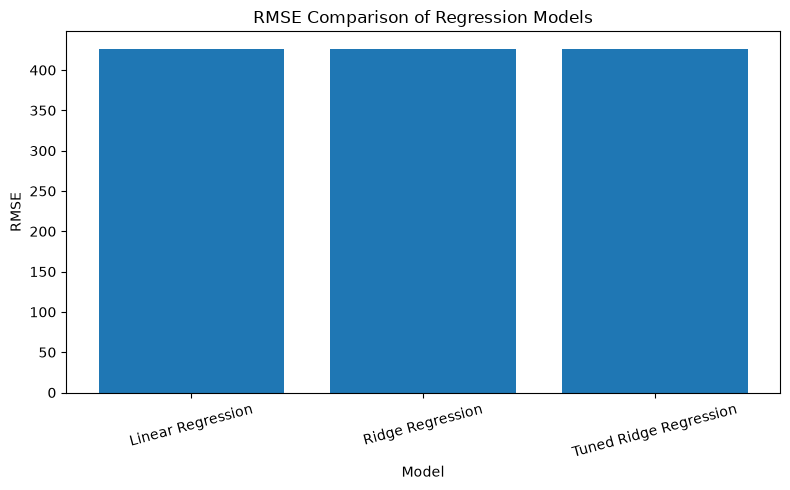

In [16]:
# Import plotting library
import matplotlib.pyplot as plt

# Model names
models = [
    "Linear Regression",
    "Ridge Regression",
    "Tuned Ridge Regression"
]

# RMSE values
rmse_values = [
    linear_rmse,
    ridge_rmse,
    tuned_ridge_rmse
]

# Create RMSE comparison chart
plt.figure(figsize=(8, 5))

plt.bar(models, rmse_values)

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Interpretation

The RMSE values of all three regression models are very similar. Linear Regression has an RMSE of 426.36, Ridge Regression has 426.37, and Tuned Ridge Regression has 426.72.

This shows that Ridge regularization and hyperparameter tuning did not significantly reduce the overall prediction error.

## 17. MAE Comparison of Regression Models

This graph compares the Mean Absolute Error (MAE) of Linear Regression, Ridge Regression, and Tuned Ridge Regression.

MAE represents the average absolute difference between the actual rental prices and the predicted rental prices. A lower MAE indicates better predictive performance.

The MAE values of the three models are very similar, indicating that Ridge regularization and hyperparameter tuning produced only a small change in the average prediction error.

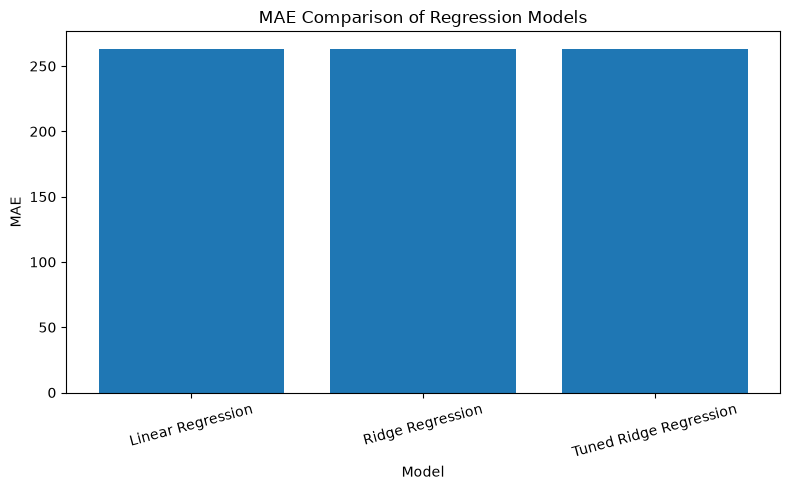

In [17]:
# MAE values for the three regression models
mae_values = [
    linear_mae,
    ridge_mae,
    tuned_ridge_mae
]

# Create MAE comparison chart
plt.figure(figsize=(8, 5))

plt.bar(models, mae_values)

plt.title("MAE Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Interpretation

The MAE values are also almost identical. Linear Regression and Ridge Regression have an MAE of 263.31, while Tuned Ridge Regression has an MAE of 263.42.

This means that the three models have a very similar average prediction error.

## 18. R² Comparison of Regression Models

This graph compares the R² scores of Linear Regression, Ridge Regression, and Tuned Ridge Regression.

R² measures how much of the variation in rental prices is explained by the model. A higher R² value indicates stronger predictive performance.

The R² scores of all three models are very similar. Linear Regression and Ridge Regression achieve approximately 0.5896, while the Tuned Ridge Regression model achieves approximately 0.5889. This shows that tuning the Ridge Regression model did not improve its predictive performance on the test dataset.

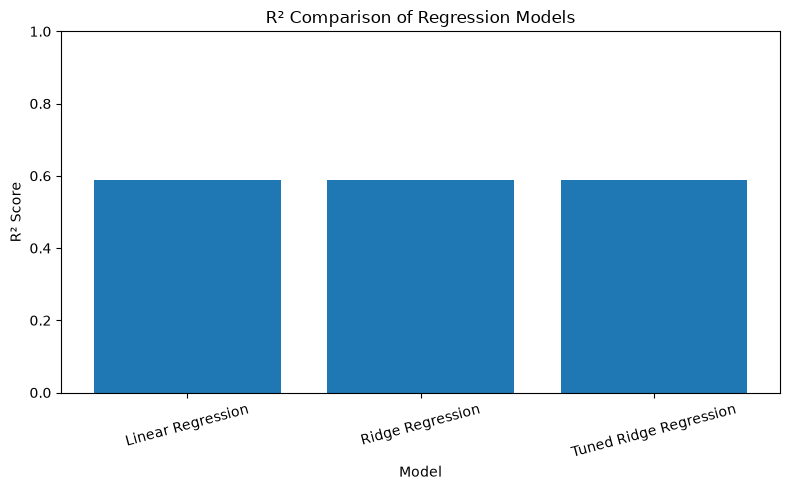

In [18]:
# R² values for the three regression models
r2_values = [
    linear_r2,
    ridge_r2,
    tuned_ridge_r2
]

# Create R² comparison chart
plt.figure(figsize=(8, 5))

plt.bar(models, r2_values)

plt.title("R² Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Interpretation

Linear Regression and Ridge Regression have an R² score of 0.5896, while Tuned Ridge Regression has an R² score of 0.5889.

This indicates that all three models explain approximately 59% of the variation in rental prices. Hyperparameter tuning did not improve the R² score.

## 19. Final Model Interpretation and Conclusion

In this notebook, Linear Regression and Ridge Regression models were developed to predict rental prices using the processed housing dataset. The models were trained using the log-transformed rental price target and evaluated on the original rental-price scale using RMSE, MAE, and R².

The Linear Regression model achieved an RMSE of 426.36, an MAE of 263.31, and an R² score of 0.5896. The initial Ridge Regression model with `alpha = 1.0` produced very similar results, with an RMSE of 426.37, an MAE of 263.31, and an R² score of 0.5896.

Ridge Regression hyperparameter tuning was then performed using 5-fold cross-validation. The tested alpha values were `0.01`, `0.1`, `1.0`, `10.0`, and `100.0`, and the selected value was `alpha = 100.0`.

The Tuned Ridge Regression model achieved an RMSE of 426.72, an MAE of 263.42, and an R² score of 0.5889. Therefore, the tuned model did not improve the test-set predictive performance compared with the original Ridge Regression or Linear Regression models.

Overall, all three models produced very similar results. An R² value of approximately 0.59 indicates that the regression models explain about 59% of the variation in rental prices in the test dataset. These results provide useful baseline performance for comparison with more flexible machine-learning models such as Random Forest.

The next stage of the project will evaluate a Random Forest regression model and compare its performance with these baseline regression models.